# Anime Recommendation System

## Setup

In [ ]:
%pip install matplotlib

## 1. Load Data

In [37]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

CSV_PATH = "anime-standalone.csv"
df_raw = pd.read_csv(CSV_PATH)
df_raw.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,48.0,2042010,1054393,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,237.0,409497,231023,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,410.0,829197,399415,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969....,7.24,3434.0,128576,46289,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,6.96,4883.0,16698,7088,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


## 2. Data Preprocessing

### 2.1 Xác định cột dữ liệu
Xác định đúng cột tên anime và thể loại từ dataset, kể cả khi tên cột thay đổi giữa các nguồn dữ liệu.

In [38]:
def _find_column(df, candidates, required=True, default=None):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"Missing required column. Expected one of: {candidates}")
    return default

title_col = _find_column(df_raw, ["title", "name", "anime_title"])
genres_col = _find_column(df_raw, ["genres", "genre"])
print("Selected columns:", title_col, genres_col)

Selected columns: title genres


### 2.2 Trích xuất các cột cần thiết
Tạo DataFrame mới chỉ gồm hai cột phục vụ gợi ý nội dung: title và genres.

In [39]:
df_anime = pd.DataFrame(
    {
        "title": df_raw[title_col].astype(str).fillna(""),
        "genres": df_raw[genres_col].astype(str).fillna(""),
    }
)

### 2.3 Làm sạch dữ liệu
Loại bỏ tiêu đề rỗng, chuẩn hóa dữ liệu genres về kiểu chuỗi để sẵn sàng cho bước TF-IDF.

In [40]:
df_anime = df_anime[df_anime["title"].str.strip() != ""].reset_index(drop=True)
df_anime["genres"] = df_anime["genres"].fillna("").astype(str)

### 2.4 Xem trước dữ liệu
Hiển thị vài dòng đầu của dữ liệu sau tiền xử lý để kiểm tra kết quả trước khi đưa vào bước TF-IDF.

In [41]:
df_anime[["title", "genres"]].head()

,title,genres
0,Cowboy Bebop,"Action, Adult Cast, Award Winning, Sci-Fi, Space"
1,Cowboy Bebop: Tengoku no Tobira,"Action, Adult Cast, Sci-Fi, Space"
2,Trigun,"Action, Adult Cast, Adventure, Sci-Fi, Shounen"
3,Witch Hunter Robin,"Action, Detective, Drama, Mystery, Supernatural"
4,Bouken Ou Beet,"Action, Adventure, Fantasy, Shounen"


## 3. TF-IDF

### 3.1 Tạo vector TF-IDF
Chuyển cột genres thành ma trận số để mô hình có thể đo mức độ tương đồng giữa các anime.

In [42]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df_anime["genres"])

### 3.2 Kiểm tra kích thước ma trận
In kích thước ma trận TF-IDF để xác nhận số lượng anime và số đặc trưng sau vector hóa.

In [43]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (24815, 96)


## 4. Cosine Similarity

### 4.1 Định nghĩa hàm lấy anime tương tự
Hàm dưới đây dùng cosine similarity để tìm Top-N anime gần nhất theo thể loại.

In [51]:
def get_top_similar_anime(title, top_n=10):
    if not title or not str(title).strip():
        raise ValueError("Vui long nhap ten anime.")

    title_lower = str(title).strip().lower()
    exact_matches = df_anime[df_anime["title"].str.lower() == title_lower]

    if exact_matches.empty:
        contains_matches = df_anime[df_anime["title"].str.lower().str.contains(title_lower, na=False)]
        if contains_matches.empty:
            raise ValueError("Khong tim thay anime trong dataset.")
        anime_index = contains_matches.index[0]
    else:
        anime_index = exact_matches.index[0]

    sim_scores = cosine_similarity(tfidf_matrix[anime_index], tfidf_matrix).flatten()
    similar_indices = sim_scores.argsort()[::-1]
    similar_indices = [idx for idx in similar_indices if idx != anime_index][:top_n]

    rec_df = df_anime.iloc[similar_indices].copy()
    rec_df["similarity"] = sim_scores[similar_indices]

    selected_title = df_anime.iloc[anime_index]["title"]
    return selected_title, rec_df[["title", "genres", "similarity"]]

### 4.2 Chạy thử với một anime mẫu
Thử truy vấn với Naruto để quan sát danh sách gợi ý và điểm tương đồng.

In [55]:
selected_title, recommendations = get_top_similar_anime("Naruto", top_n=20)
print("Selected anime:", selected_title)
recommendations

Selected anime: Naruto


,title,genres,similarity
rank,,,
1,Naruto: Takigakure no Shitou - Ore ga Eiyuu Da...,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
2,Naruto: Shippuuden,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
3,Dragon Ball Super: Super Hero,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
4,Boruto: Naruto Next Generations,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
5,Dragon Ball Z Movie 14: Kami to Kami,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
6,Boruto: Jump Festa 2016 Special,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
7,Boruto: Naruto the Movie,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
8,Dragon Ball Super: Broly,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
9,Juushin Enbu: Hero Tales,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000


### 4.3 Similarity Score Explanation
- Điểm gần 1: thể loại rất giống nhau.
- Điểm gần 0: thể loại rất khác nhau.
- Hệ thống sẽ sắp xếp các anime gợi ý theo thứ tự từ điểm tương đồng cao xuống thấp.

## 5. Visualization

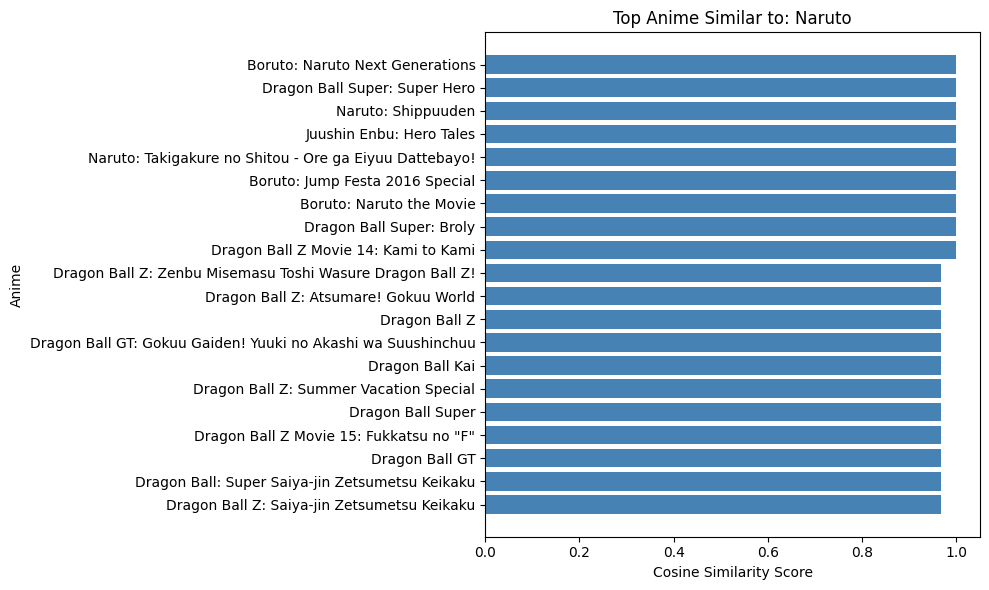

In [56]:
plot_df = recommendations.sort_values("similarity", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["title"], plot_df["similarity"], color="steelblue")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Anime")
plt.title(f"Top Anime Similar to: {selected_title}")
plt.tight_layout()
plt.show()